In [1]:
# transformers: Hugging Face library for BERT and other models
# datasets: Hugging Face library for loading datasets easily
# accelerate: speeds up training
# gradio: builds interactive web demos with minimal code
# evaluate: calculates metrics like accuracy and F1
!pip install transformers datasets accelerate gradio evaluate scikit-learn --quiet
print('All libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
All libraries installed!


In [2]:
# AutoTokenizer: automatically loads the right tokenizer for any model
# Tokenizer converts text → numbers that BERT can understand
from transformers import AutoTokenizer

# AutoModelForSequenceClassification: loads BERT for text classification
# Sequence Classification = assigning a label to a whole text
from transformers import AutoModelForSequenceClassification

# TrainingArguments: all training settings (epochs, batch size, etc.)
# Trainer: runs the training loop automatically
from transformers import TrainingArguments, Trainer

# load_dataset: downloads and loads datasets from Hugging Face
from datasets import load_dataset

# evaluate: calculates accuracy, F1 score etc.
import evaluate

# numpy for numerical operations
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn for confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

All imports successful!


In [3]:
# Load the AG News dataset from Hugging Face
# This dataset has news headlines labeled with 4 categories
print('Loading AG News dataset...')
dataset = load_dataset('ag_news')

print('Dataset loaded!')
print('Keys:', dataset.keys())
print('Training samples:', len(dataset['train']))
print('Test samples:', len(dataset['test']))
print()

# Show first example
print('First sample:')
print(dataset['train'][0])

Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset loaded!
Keys: dict_keys(['train', 'test'])
Training samples: 120000
Test samples: 7600

First sample:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


Label mapping:
  0 → World
  1 → Sports
  2 → Business
  3 → Sci/Tech


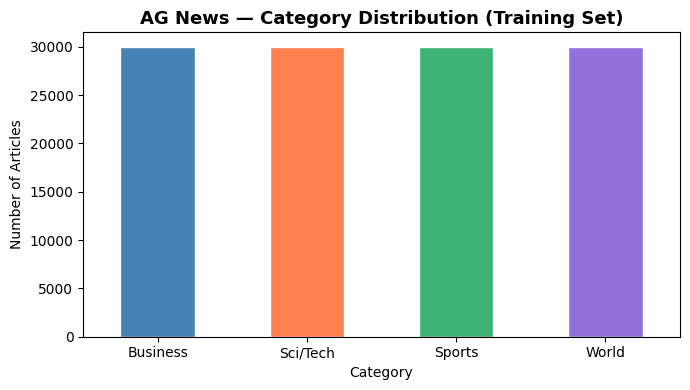

Dataset is perfectly balanced — each category has equal samples!


In [4]:
# AG News has 4 label numbers: 0, 1, 2, 3
# Each number corresponds to a topic
# We define human-readable names for each label

# label2id: text name → number (for the model)
# id2label: number → text name (for reading results)
id2label = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
label2id = {'World': 0, 'Sports': 1, 'Business': 2, 'Sci/Tech': 3}

print('Label mapping:')
for id, label in id2label.items():
    print(f'  {id} → {label}')

# Count samples per category
import pandas as pd
train_labels = [id2label[x] for x in dataset['train']['label']]
label_counts = pd.Series(train_labels).value_counts()

plt.figure(figsize=(7, 4))
label_counts.plot(kind='bar', color=['steelblue','coral','mediumseagreen','mediumpurple'], edgecolor='white')
plt.title('AG News — Category Distribution (Training Set)', fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Dataset is perfectly balanced — each category has equal samples!')

In [5]:
# Load BERT's tokenizer
# 'bert-base-uncased' = BERT model, base size, treats 'Apple' same as 'apple'
MODEL_NAME = 'bert-base-uncased'
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Define a function to tokenize our text
def tokenize_function(examples):
    return tokenizer(
        examples['text'],         # the text column to tokenize
        padding='max_length',     # pad short texts to same length
        truncation=True,          # cut long texts to max length
        max_length=128            # max 128 tokens (enough for headlines)
    )

# Use a SMALL subset to keep training fast
# AG News has 120,000 training samples — too many for a laptop
# We use 2000 for training, 500 for testing
print('Selecting small subset for fast training...')
small_train = dataset['train'].shuffle(seed=42).select(range(2000))
small_test  = dataset['test'].shuffle(seed=42).select(range(500))

# Apply tokenization to all samples
# batched=True processes multiple samples at once (faster)
print('Tokenizing data...')
train_tokenized = small_train.map(tokenize_function, batched=True)
test_tokenized  = small_test.map(tokenize_function, batched=True)

print('Tokenization complete!')
print('Training samples:', len(train_tokenized))
print('Test samples:', len(test_tokenized))

Loading tokenizer: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Selecting small subset for fast training...
Tokenizing data...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenization complete!
Training samples: 2000
Test samples: 500


In [6]:
# Load BERT with 4 output classes (one per news category)
# num_labels=4 adds a classification layer with 4 outputs
# id2label and label2id tell BERT what each number means
print('Loading BERT model...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,          # 4 news categories
    id2label=id2label,     # number to label mapping
    label2id=label2id      # label to number mapping
)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded!')
print(f'Total parameters: {total_params:,}')  # BERT has ~110 million parameters!

Loading BERT model...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
Total parameters: 109,485,316


In [7]:
# Load the accuracy metric from the evaluate library
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    """
    Called automatically during training to calculate metrics.
    - logits: raw scores for each class (before converting to probabilities)
    - labels: the correct answers
    """
    logits, labels = eval_pred

    # argmax finds the index of the highest score
    # That index = the predicted class
    # Example: logits=[0.1, 0.7, 0.1, 0.1] → argmax=1 → 'Sports'
    predictions = np.argmax(logits, axis=-1)

    # Calculate accuracy
    acc = accuracy_metric.compute(predictions=predictions, references=labels)

    return acc


print('Metrics function ready!')

Metrics function ready!


In [8]:
# TrainingArguments: all the settings for training
training_args = TrainingArguments(

    output_dir='./bert_news_classifier',  # folder to save model checkpoints

    num_train_epochs=3,         # train for 3 full passes through the data
                                # 1 epoch = model sees all training data once

    per_device_train_batch_size=16,  # process 16 samples at a time during training
    per_device_eval_batch_size=32,   # process 32 samples at a time during evaluation

    warmup_steps=100,           # gradually increase learning rate for first 100 steps
                                # prevents model from making too big jumps at start

    weight_decay=0.01,          # prevents model from overfitting
                                # overfitting = model memorizes training data, fails on new data

    eval_strategy='epoch',      # evaluate after each epoch
    save_strategy='epoch',      # save model after each epoch

    load_best_model_at_end=True, # at the end, load the epoch with best accuracy

    logging_steps=50,           # print progress every 50 steps

    report_to='none'            # don't send logs to wandb or other trackers
)

# Trainer: handles the entire training loop automatically
# No need to write for loops, backward passes, etc.
trainer = Trainer(
    model=model,                       # our BERT model
    args=training_args,                # training settings
    train_dataset=train_tokenized,     # training data
    eval_dataset=test_tokenized,       # evaluation data
    compute_metrics=compute_metrics    # our metrics function
)

# Start fine-tuning!
print('Starting BERT fine-tuning...')
trainer.train()

print('Fine-tuning complete!')

# Save the final model
model.save_pretrained('./bert_news_classifier')
tokenizer.save_pretrained('./bert_news_classifier')
print('Model saved to ./bert_news_classifier')

Starting BERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.528838,0.390594,0.874000
2,0.262333,0.377031,0.890000
3,0.114371,0.400359,0.894000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Fine-tuning complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert_news_classifier


In [9]:
# Run evaluation on the test set
print('Evaluating model...')
results = trainer.evaluate()

print()
print('Evaluation Results:')
print(f'  Accuracy: {results["eval_accuracy"]*100:.2f}%')
print(f'  Loss:     {results["eval_loss"]:.4f}')

Evaluating model...



Evaluation Results:
  Accuracy: 89.00%
  Loss:     0.3768


Detailed Classification Report:
              precision    recall  f1-score   support

    Business       0.84      0.87      0.86       134
    Sci/Tech       0.83      0.90      0.87       125
      Sports       0.94      0.98      0.96       121
       World       0.97      0.80      0.88       120

    accuracy                           0.89       500
   macro avg       0.90      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



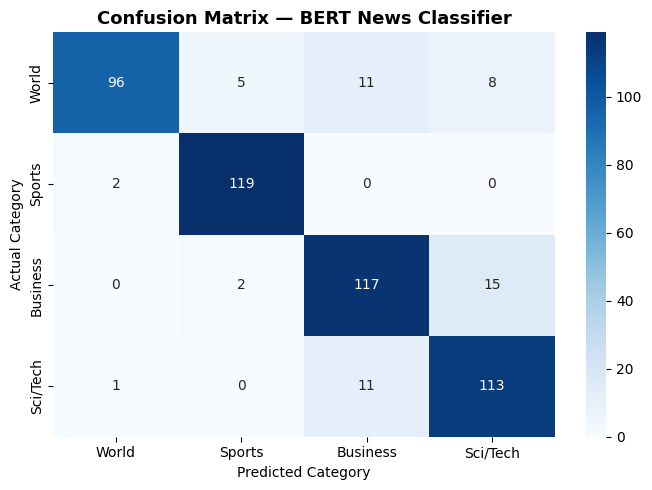

Diagonal cells = correct predictions
Off-diagonal = incorrect predictions (mistakes)


In [10]:
# ---- Detailed Evaluation with Confusion Matrix ----

# Get predictions for all test samples
predictions_output = trainer.predict(test_tokenized)

# Convert logits to predicted labels
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# Convert numbers back to label names for readability
y_pred_names = [id2label[p] for p in y_pred]
y_true_names = [id2label[t] for t in y_true]

# Print detailed classification report
# Precision: of all predicted 'Sports', how many were actually Sports?
# Recall: of all actual 'Sports', how many did we correctly predict?
# F1: harmonic mean of precision and recall
print('Detailed Classification Report:')
print(classification_report(y_true_names, y_pred_names))

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true_names, y_pred_names, labels=list(id2label.values()))

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(id2label.values()),
    yticklabels=list(id2label.values())
)
plt.title('Confusion Matrix — BERT News Classifier', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.tight_layout()
plt.show()
print('Diagonal cells = correct predictions')
print('Off-diagonal = incorrect predictions (mistakes)')

In [11]:
# gradio: builds interactive web apps with minimal code
import gradio as gr

# torch: PyTorch — needed for running the model
import torch

# Import model and tokenizer loaders from Hugging Face
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ---- Load the saved model and tokenizer from disk ----
# We saved these after training in the previous step
# Now we reload them for the Gradio demo
print("Loading model for Gradio...")

# Load the tokenizer that converts text → numbers
saved_tokenizer = AutoTokenizer.from_pretrained('./bert_news_classifier')

# Load the fine-tuned BERT classification model
saved_model = AutoModelForSequenceClassification.from_pretrained('./bert_news_classifier')

# Set model to evaluation mode
# eval() turns OFF dropout layers (used during training to prevent overfitting)
# During prediction we want consistent, deterministic results
saved_model.eval()
print("Model ready!")

# Label mapping: number → category name
# BERT outputs numbers (0,1,2,3), we convert them to readable names
id2label = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

def predict_news_category(headline):
    """
    Takes a news headline as input.
    Returns the predicted category with confidence scores.
    """

    # Check if user typed anything
    # If input is empty, return a helpful message
    if not headline or headline.strip() == "":
        return "Please type a news headline!"

    try:
        # ---- Step 1: Tokenize the input headline ----
        # Convert raw text into numbers that BERT understands
        # return_tensors='pt' means return PyTorch tensors (not numpy)
        # truncation=True cuts text longer than 128 tokens
        # padding=True adds zeros to make all inputs same length
        inputs = saved_tokenizer(
            headline,
            return_tensors='pt',
            truncation=True,
            max_length=128,
            padding=True
        )

        # ---- Step 2: Run the model to get predictions ----
        # torch.no_grad() tells PyTorch: do NOT calculate gradients
        # Gradients are only needed during TRAINING (to update weights)
        # During PREDICTION we don't need them — saves memory and speeds up
        with torch.no_grad():
            # ** unpacks the inputs dictionary as keyword arguments
            # Same as: saved_model(input_ids=..., attention_mask=...)
            outputs = saved_model(**inputs)

        # ---- Step 3: Convert raw scores to probabilities ----
        # outputs.logits = raw scores for each class
        # Example: [-1.2,  3.5, -0.8,  0.3] (not yet probabilities)
        # softmax converts these to probabilities that ADD UP TO 1.0
        # Example: [0.05, 0.85, 0.06, 0.04] → Sports is most likely
        # dim=-1 means apply softmax across the last dimension (classes)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

        # Convert from PyTorch tensor to a regular Python list
        probs = probs[0].tolist()

        # ---- Step 4: Build a readable result ----
        # Create a dictionary: {category_name: probability_percentage}
        # round(..., 2) keeps 2 decimal places
        result = {id2label[i]: round(p * 100, 2) for i, p in enumerate(probs)}

        # Find the category with the HIGHEST probability
        # max(..., key=result.get) finds the key with the largest value
        top_label = max(result, key=result.get)
        top_prob  = result[top_label]

        # ---- Step 5: Format the output string ----
        # This is what the user will see in the Gradio interface
        output = f"Predicted: {top_label} ({top_prob:.1f}% confident)\n\n"

        # Show all 4 categories with probabilities sorted highest to lowest
        # Also adds a simple visual bar using block characters
        for label, prob in sorted(result.items(), key=lambda x: x[1], reverse=True):
            bar = '█' * int(prob / 5)   # 1 block per 5% — visual representation
            output += f"{label:10s}: {prob:5.1f}% {bar}\n"

        return output

    except Exception as e:
        # If anything goes wrong, show the error message
        # This prevents the app from crashing silently
        return f"Error: {str(e)}"

# gr.Interface creates the web app
# fn       = the function to call when user submits
# inputs   = what the user sees as input (text box)
# outputs  = what the user sees as output (text box)
# title    = heading shown on the web page
# description = subtitle shown under the heading
demo = gr.Interface(
    fn=predict_news_category,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Type a news headline here..."
    ),
    outputs=gr.Textbox(label="Prediction"),
    title="News Topic Classifier (BERT)",
    description="Classifies headlines into: World, Sports, Business, Sci/Tech"
)

# Launch the Gradio app
# share=True creates a PUBLIC link that anyone can open
# The link looks like: https://xxxx.gradio.live
# It stays active for 72 hours on free Colab
demo.launch(share=True)

Loading model for Gradio...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model ready!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://405d4c75f55f0c3f2e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
